# ML Pipeline

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import(
    train_test_split,
    StratifiedKFold
)
from sklearn.svm import SVC
from sklearn.preprocessing import (
    StandardScaler,
    PowerTransformer
)
from sklearn.metrics import(
    f1_score,
    precision_score,
    recall_score,
    roc_curve, 
    auc,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from itertools import product

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset
df = pd.read_csv("Datasets/Botswana_GAD_eGeMAPS_QBF.csv")

# Modify GAD7 binary classification
df['Anxiety_Binary'] = df['GAD7_Total'].apply(lambda x: 'Anxious' if x >= 5 else 'Non-Anxious')

# Deep copy the dataset for machine learning
ml_df = df.copy()
ml_df.drop(columns=['SessionID', 'QBF_Name', 'Sex', 'Age'], inplace=True)

# Encode anxiety categories
anxiety_category_map = {"Minimal": 0, "Mild": 1, "Moderate": 2, "Severe": 3}
anxiety_binary_map = {"Non-Anxious": 0, "Anxious": 1}
ml_df['Anxiety_Category'] = ml_df['Anxiety_Category'].map(anxiety_category_map)
ml_df['Anxiety_Binary'] = ml_df['Anxiety_Binary'].map(anxiety_binary_map)

# Acoustic Features
acoustic_features = ml_df.columns[6:]
stddev_features = [col for col in acoustic_features if 'stddev' in col.lower()]

# Data preparation
X = ml_df[acoustic_features]
y = ml_df['Anxiety_Binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Outlier detection
def IQR_OutlierDetection(X, lower_quantile=0.025, upper_quantile=0.975):
    Q1 = X.quantile(lower_quantile)
    Q3 = X.quantile(upper_quantile)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - IQR
    upper_bound = Q3 + IQR
    
    mask_inlier_df = (X >= lower_bound) & (X <= upper_bound)
    
    mask_inlier = mask_inlier_df.all(axis=1)
    
    return mask_inlier

# Define the pipeline
pipeline = ImbPipeline([
    ("yjpt", PowerTransformer(method='yeo-johnson', standardize=False)),
    ("scaler", StandardScaler()),
    ("oversampling", SMOTE(random_state=42)),
    ("clf", SVC(kernel="rbf", probability=True, random_state=42))
])

# Define the parameter grid
param_grid = {
    'oversampling__k_neighbors': [3, 5],
    'clf__C': np.logspace(-3, 3, 7),
    'clf__gamma': np.logspace(-4, 1, 6)
}

# Set up stratified K-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Generate all parameter combinations
param_combinations = list(product(
    param_grid['oversampling__k_neighbors'],
    param_grid['clf__C'],
    param_grid['clf__gamma']
))

# Custom grid search loop
best_f1_score = -np.inf
best_precision_score = -np.inf
best_recall_score = -np.inf
best_params = None
best_model = None

best_tprs = []
best_aucs = []
best_precisions = []
best_aps = []
mean_fpr = np.linspace(0, 1, 100)
mean_recall = np.linspace(0, 1, 100)

for params in param_combinations:
    # Unpack parameters
    oversampling_k_neighbors, clf_c, clf_gamma = params
    
    # Set pipeline parameters
    pipeline.set_params(
        oversampling__k_neighbors=oversampling_k_neighbors,
        clf__C=clf_c,
        clf__gamma=clf_gamma
    )
    
    # Initialize scores for this parameter combination
    f1_scores, precision_scores, recall_scores = [], [], []
    tprs, fprs, aucs, precisions, aps = [], [], [], [], []
    
    # Perform cross-validation
    for train_index, val_index in cv.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

        # Outlier detection
        mask_inliers = IQR_OutlierDetection(X_fold_train)
        X_fold_train_inliers = X_fold_train[mask_inliers]
        y_fold_train_inliers = y_fold_train[mask_inliers]
        
        # Fit the pipeline
        pipeline.fit(X_fold_train_inliers, y_fold_train_inliers)

        # Evaluate the pipeline
        y_fold_pred = pipeline.predict(X_fold_val)
        f1_scores.append(f1_score(y_fold_val, y_fold_pred, average='binary'))
        precision_scores.append(precision_score(y_fold_val, y_fold_pred, average='binary', zero_division=0))
        recall_scores.append(recall_score(y_fold_val, y_fold_pred, average='binary', zero_division=0))

        # Compute ROC curve, AUC and & interpolate TPR to common FPR points 
        y_fold_proba = pipeline.predict_proba(X_fold_val)[:, 1]
        fpr, tpr, _ = roc_curve(y_fold_val, y_fold_proba)
        auc_score = auc(fpr, tpr)
        aucs.append(auc_score)
        
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0  # Ensure TPR starts at 0
        tprs.append(interp_tpr)
        fprs.append(fpr)
        
        # Compute Precision-Recall curve
        precision, recall, _ = precision_recall_curve(y_fold_val, y_fold_proba)
        ap_score = average_precision_score(y_fold_val, y_fold_proba)  # Average precision
        aps.append(ap_score)

        interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])  # Reverse order of recall and precision to align with mean_recall
        precisions.append(interp_precision)
        
        print(f"Fold f1-score: {f1_scores[-1]:.4f}, precision: {precision_scores[-1]:.4f}, recall: {recall_scores[-1]:.4f}, AUC: {auc_score:.4f}, AP: {ap_score:.4f}")

    # Compute average scores
    avg_f1 = np.mean(f1_scores)
    avg_precision = np.mean(precision_scores)
    avg_recall = np.mean(recall_scores)
    avg_auc = np.mean(aucs)
    avg_ap = np.mean(aps)
    print(f"Params: {params} => Avg F1: {avg_f1:.4f}, Avg Precision: {avg_precision:.4f}, Avg Recall: {avg_recall:.4f}, Avg AUC: {avg_auc:.4f}, Avg AP: {avg_ap:.4f}")
    
    # Update best scores and parameters
    if avg_f1 > best_f1_score:
        best_f1_score = avg_f1
        best_precision_score = avg_precision
        best_recall_score = avg_recall
        best_params = params
        best_model = pipeline
        best_tprs = tprs
        best_aucs = aucs
        best_precisions = precisions
        best_aps = aps

# Output the best parameters and scores
print("Best F1 Score:", best_f1_score)
print("Best Precision Score:", best_precision_score)
print("Best Recall Score:", best_recall_score)
print("Best Parameters:", best_params)
print("Best Mean AUC:", np.mean(best_aucs))
print("Best Mean AP:", np.mean(best_aps))

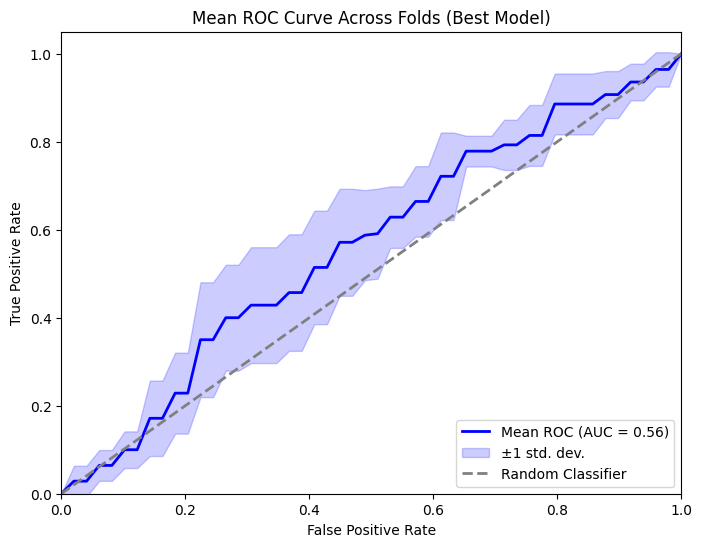

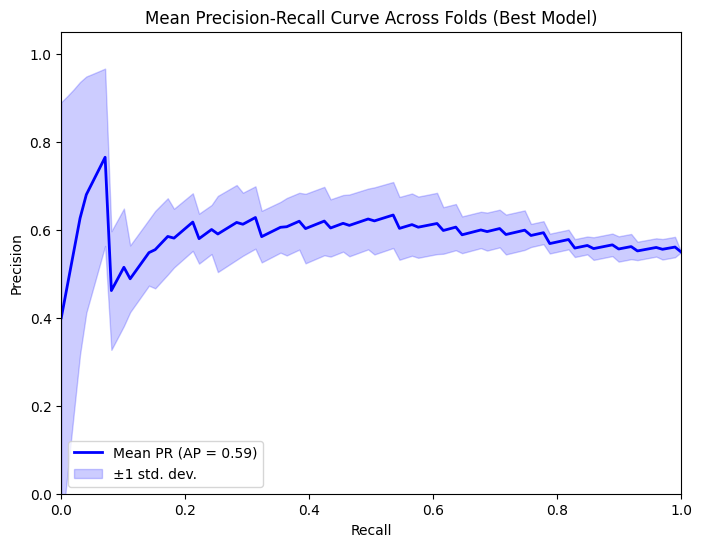

In [45]:
# Plot ROC curve for the best model
mean_tpr = np.mean(best_tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_tpr = np.std(best_tprs, axis=0)

plt.figure(figsize=(8, 6))
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2)
plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color='b', alpha=0.2, label='±1 std. dev.')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Mean ROC Curve Across Folds (Best Model)')
plt.legend(loc='lower right')
plt.show()

# Plot Precision-Recall curve for the best model
mean_precision = np.mean(best_precisions, axis=0)
mean_ap = np.mean(best_aps)
std_precision = np.std(best_precisions, axis=0)

plt.figure(figsize=(8, 6))
plt.plot(mean_recall, mean_precision, color='b', label=f'Mean PR (AP = {mean_ap:.2f})', lw=2)
plt.fill_between(mean_recall, mean_precision - std_precision, mean_precision + std_precision, color='b', alpha=0.2, label='±1 std. dev.')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Mean Precision-Recall Curve Across Folds (Best Model)')
plt.legend(loc='lower left')
plt.show()

In [ ]:
# Fit the best model on the entire training set
mask_inliers = IQR_OutlierDetection(X_train)
X_train_inliers = X_train[mask_inliers]
y_train_inliers = y_train[mask_inliers]
best_model.fit(X_train_inliers, y_train_inliers)

# Evaluate on test set
y_pred_test = best_model.predict(X_test)
print("\nTest Set Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=anxiety_binary_map.keys()))
cm = confusion_matrix(y_test, y_pred_test)
cm